# Предсказание возраста посетителей сайтов

## План работы
- Построить модель машинного обучения, которая по данным о поведении анонимного пользователя в цифровой среде будет определять его примерный возраст.
- Поле которое является целевой переменной `age_category`.
- Оценка модели по ключевой метрике F1-score. Вспомогательные метрики качества: precision и recall.
- Значение F1-меры лучшей модели должно быть не меньше 0.75 и на кросс-валидации по обучающей выборке, и на тестовой выборке.

## 1. Подготовка среды и библиотек

#### 1.1 Подготовка библиотек


In [1]:
!pip install phik -U -q
!pip install scikit-learn -U -q

In [2]:
#Импорт библиотек
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import phik
from time import time
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import (
    calibration_curve,
    CalibrationDisplay,
    CalibratedClassifierCV
)
from sklearn.frozen import FrozenEstimator
import joblib

#### 1.2 Фиксация константы для воспроизводимости

In [3]:
# Зафиксируем константы для воспроизводимости
RANDOM_STATE = 42
N_FOLDS = 5

#### 1.3 Загрузка данных

In [4]:
datasets = dict(
    links=dict(
        users='/datasets/ds_s13_users.csv',
        visits='/datasets/ds_s13_visits.csv',
        ads_activity='/datasets/ads_activity.csv',
        surf_depth='/datasets/surf_depth.csv',
        primary_device='/datasets/primary_device.csv',
        cloud_usage='/datasets/cloud_usage.csv',
    )
)

In [5]:
for name, link in datasets['links'].items():
    try:
        datasets[name] = pd.read_csv(datasets['links'][name], sep=',', decimal='.')
    except FileNotFoundError as e:
        print(f'Ошибка загрузки файла {datasets['links'][name]}')
        'https://code.s3.yandex.net/'
        link = 'https://code.s3.yandex.net' + datasets['links'][name]
        datasets[name] = pd.read_csv(link, sep=',', decimal='.')
        print(f'Загружен файл {link}')


Ошибка загрузки файла /datasets/ds_s13_users.csv
Загружен файл https://code.s3.yandex.net/datasets/ds_s13_users.csv
Ошибка загрузки файла /datasets/ds_s13_visits.csv
Загружен файл https://code.s3.yandex.net/datasets/ds_s13_visits.csv
Ошибка загрузки файла /datasets/ads_activity.csv
Загружен файл https://code.s3.yandex.net/datasets/ads_activity.csv
Ошибка загрузки файла /datasets/surf_depth.csv
Загружен файл https://code.s3.yandex.net/datasets/surf_depth.csv
Ошибка загрузки файла /datasets/primary_device.csv
Загружен файл https://code.s3.yandex.net/datasets/primary_device.csv
Ошибка загрузки файла /datasets/cloud_usage.csv
Загружен файл https://code.s3.yandex.net/datasets/cloud_usage.csv


#### 1.4 Предобработка данных

In [6]:
datasets['visits'].info()

<class 'pandas.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype
---  ------            --------------    -----
 0   date              1065745 non-null  str  
 1   daytime           1065745 non-null  str  
 2   session_id        1065745 non-null  str  
 3   user_id           1065745 non-null  str  
 4   website_category  1065745 non-null  str  
dtypes: str(5)
memory usage: 40.7 MB


In [7]:
datasets['visits'].head()

,date,daytime,session_id,user_id,website_category
0,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 17
1,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 19
2,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 18
3,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 20
4,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 05


Датасет `ds_s13_visits.csv` содержит 5 столбцов и 1065745 строк, в которых представлена информация о посещениях сайтов пользователями.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов уже приведены к одному виду.
- Столбцы `date` содержит информацию о дате и хранится в типк данных `str`, тип данных следует привести к типу `datetime64`.
- Столбец `daytime` содержит категориальную информацию и хранится в типе данных `str`, тип данных следует преобразовать в `category`.
- Столбец `session_id` содержит категориальную информацию и хранится в типе данных `str`, изменять тип данных не требуется.
- Столбец `user_id` содержит категориальную информацию и хранится в типе данных `str`, изменять тип данных не требуется.
- Столбец `website_category` содержит категориальную информацию и хранится в типе данных `str`, тип данных следует преобразовать в `category`.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

In [8]:
datasets['users'].info()

<class 'pandas.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5913 non-null   str  
 1   age_category  5913 non-null   int64
dtypes: int64(1), str(1)
memory usage: 92.5 KB


In [9]:
datasets['users'].head()

,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0


Датасет `ds_s13_users.csv` содержит 2 столбца и 5913 строк, в которых представлена информация о пользователях.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов уже приведены к одному виду.
- Столбец `user_id` содержит категориальную информацию и хранится в типе данных `str`, изменять тип данных не требуется.
- Столбец `age_category` содержит категориальную информацию и хранится в типе данных `int64`, тип данных следует преобразовать в `category`.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

In [10]:
datasets['ads_activity'].info()

<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5826 non-null   str  
 1   ads_activity  5826 non-null   str  
dtypes: str(2)
memory usage: 91.2 KB


In [11]:
datasets['ads_activity'].head()

,user_id,ads_activity
0,e318-d8e69c86b543a5fb927c-c36fb6e6,очень часто
1,35cd-a972339dec534f49332c-a8b6d383,редко
2,f7e6-3b29cf9cb7ed4bb00d8f-81534360,очень редко
3,5186-e25a37549e50f45b2b43-178eaabe,умеренно
4,febd-077f277466253ee04ef6-42656680,умеренно


Датасет `ads_activity.csv` содержит 2 столбца и 5826 строк, в которых представлена информация об активности взаимодействия пользователя с рекламными объявлениями.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов уже приведены к одному виду.
- Столбец `user_id` содержит категориальную информацию и хранится в типе данных `str`, изменять тип данных не требуется.
- Столбец `ads_activity` содержит категориальную информацию и хранится в типе данных `str`, тип данных следует преобразовать в `category`.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

In [12]:
datasets['surf_depth'].info()

<class 'pandas.DataFrame'>
RangeIndex: 5715 entries, 0 to 5714
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     5715 non-null   str  
 1   surf_depth  5715 non-null   str  
dtypes: str(2)
memory usage: 89.4 KB


In [13]:
datasets['surf_depth'].head()

,user_id,surf_depth
0,f238-0c4c1e787cce311541b7-736925a0,поверхностно
1,9030-1b562ad80182b6dc27f1-ce811740,глубоко
2,22e0-7c6cadcc45e246b8688d-c43c9b23,поверхностно
3,9d7f-a19f10756378940a49b5-5d03e1ef,поверхностно
4,4233-bb5ae4b09827e5497094-1a4956af,глубоко


Датасет `surf_depth.csv` содержит 2 столбца и 5715 строк, в которых представлена информация о глубине перехода пользователей по сайтам.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов уже приведены к одному виду.
- Столбец `user_id` содержит категориальную информацию и хранится в типе данных `str`, изменять тип данных не требуется.
- Столбец `surf_depth` содержит категориальную информацию и хранится в типе данных `str`, тип данных следует преобразовать в `category`.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

In [14]:
datasets['primary_device'].info()

<class 'pandas.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   user_id         5669 non-null   str  
 1   primary_device  5669 non-null   str  
dtypes: str(2)
memory usage: 88.7 KB


In [15]:
datasets['primary_device'].head()

,user_id,primary_device
0,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
1,9204-9558455be649d4e77945-b5e25d62,ПК
2,5eea-22babd6a9474b43b9d0b-a39a4cf2,ноутбук
3,c142-0296948e8d08e417de10-2da9523c,смартфон
4,abec-bb4092da51eb2233a928-e44ba074,ПК


Датасет `primary_device.csv` содержит 2 столбца и 5669 строк, в которых представлена информация об основноми типе устройства пользователя.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов уже приведены к одному виду.
- Столбец `user_id` содержит категориальную информацию и хранится в типе данных `str`, изменять тип данных не требуется.
- Столбец `primary_device` содержит категориальную информацию и хранится в типе данных `str`, тип данных следует преобразовать в `category`.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

In [16]:
datasets['cloud_usage'].info()

<class 'pandas.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      5680 non-null   str  
 1   cloud_usage  5680 non-null   bool 
dtypes: bool(1), str(1)
memory usage: 50.1 KB


In [17]:
datasets['cloud_usage'].head()

,user_id,cloud_usage
0,a1e4-91c8a52eb855595e653f-298ce305,False
1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False
2,0d55-9ad768879e9b08ca7ff9-843f76c7,True
3,4baa-43285d10a6d3cc969f2a-b21881d1,False
4,b8cd-cbb2411db005115ca64d-32700c62,False


Датасет `cloud_usage.csv` содержит 2 столбца и 5680 строк, в которых представлена информация об основноми типе устройства пользователя.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов уже приведены к одному виду.
- Столбец `user_id` содержит категориальную информацию и хранится в типе данных `str`, изменять тип данных не требуется.
- Столбец `cloud_usage` содержит бинарный признактипе данных `bool`, тип данных можно оставить без изменений.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

In [18]:
# Класс оптимизации типов данных датафрейма
class DataFrameNormalizer:
    def __init__(self, df):
        self.df = df

    def run(self,
        to_int: list = None,
        to_float: list = None,
        to_category: list = None,
        to_date: list = None
    ) -> pd.DataFrame:
        original_df = self.df.copy()
        if to_int:
            self.to_int(to_int)
        if to_float:
            self.to_float(to_float)
        if to_category:
            self.to_category(to_category)
        if to_date:
            self.to_date(to_date)
        return pd.concat([
            original_df.dtypes.rename('До изменений'),
            self.df.dtypes.rename('После изменений')
        ], axis=1)

    def to_int(self, columns: list) -> None:
        for column in columns:
            self.df[column] = pd.to_numeric(self.df[column], downcast='integer')

    def to_float(self, columns: list) -> None:
        for column in columns:
            self.df[column] = pd.to_numeric(self.df[column], downcast='float')

    def to_category(self, columns: list) -> None:
        for column in columns:
            self.df[column] = self.df[column].astype('category')

    def to_date(self, columns: list) -> None:
        for column in columns:
            self.df[column] = pd.to_datetime(self.df[column].astype(str))

In [19]:
# Копирование датасета и нормализация типов данных в нем
visits_df = datasets['visits'].copy()
datetimes = ('date',)
categories = ('daytime', 'website_category')
DataFrameNormalizer(visits_df).run(to_category=categories, to_date=datetimes)

,До изменений,После изменений
date,str,datetime64[us]
daytime,str,category
session_id,str,str
user_id,str,str
website_category,str,category


#### 1.5 Создание профиля пользователя

In [63]:
# Подготовка витрины данных для датасета visits
visits_df['weekday'] = visits_df['date'].dt.dayofweek
visits_df['day_of_month'] = visits_df['date'].dt.day
user_features = visits_df.groupby('user_id').agg(
    unique_sessions=('session_id', 'nunique'),
    total_actions=('session_id', 'count'),
    active_days=('date', 'nunique'),

    actions_in_preferred_day_of_month=('day_of_month', lambda x: x.value_counts().max()),
    preferred_day_of_month=('day_of_month', lambda x: x.mode()[0] if len(x.mode()) > 0 else None),
    total_days_span=('date', lambda x: (x.max() - x.min()).days if len(x) > 1 else 0),
    actions_per_session=('session_id', lambda x: len(x) / x.nunique()),
    actions_per_active_day=('date', lambda x: len(x) / x.nunique()),

    actions_in_preferred_weekday=('weekday', lambda x: x.value_counts().max()),
    preferred_weekday=('weekday', lambda x: x.mode()[0] if len(x.mode()) > 0 else None),
    preferred_weekday_ratio=('weekday', lambda x: x.value_counts().max() / len(x) if len(x) > 0 else 0),

    preferred_daytime=('daytime', lambda x: x.mode()[0] if len(x.mode()) > 0 else None),
    first_daytime=('daytime', 'first'),
    last_daytime=('daytime', 'last'),
    actions_in_preferred_daytime=('daytime', lambda x: x.value_counts().max()),
    preferred_daytime_ratio=('daytime', lambda x: x.value_counts().max() / len(x) if len(x) > 0 else 0),

    unique_categories=('website_category', 'nunique'),
    preferred_category=('website_category', lambda x: x.mode()[0] if len(x.mode()) > 0 else None),
    first_category=('website_category', 'first'),
    last_category=('website_category', 'last'),
    preferred_category_ratio=('website_category', lambda x: x.value_counts().max() / len(x) if len(x) > 0 else 0),
).reset_index()

#### 1.6 Объединение датасетов

In [64]:
# Произведем слияние датафреймов
df = pd.merge(datasets['users'], user_features, on='user_id', how='outer')
df =  pd.merge(df, datasets['ads_activity'], on='user_id', how='outer')
df =  pd.merge(df, datasets['surf_depth'], on='user_id', how='outer')
df =  pd.merge(df, datasets['primary_device'], on='user_id', how='outer')
df =  pd.merge(df, datasets['cloud_usage'], on='user_id', how='outer')

In [65]:
#Выведем отчет по датасету df
df.describe()

,age_category,unique_sessions,total_actions,active_days,actions_in_preferred_day_of_month,preferred_day_of_month,total_days_span,actions_per_session,actions_per_active_day,actions_in_preferred_weekday,preferred_weekday,preferred_weekday_ratio,actions_in_preferred_daytime,preferred_daytime_ratio,unique_categories,preferred_category_ratio
count,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000,6146.000000
mean,2.446307,180.075984,182.782786,13.998536,19.537911,6.977384,12.999675,1.014947,13.056756,33.232184,2.842011,0.184652,72.228441,0.396471,18.474780,0.126104
std,1.380250,74.912149,76.110776,0.038242,6.896063,4.022796,0.018038,0.009774,5.435668,12.553622,2.006807,0.017914,29.848359,0.032274,0.765041,0.030781
min,0.000000,100.000000,100.000000,13.000000,9.000000,1.000000,12.000000,1.000000,7.142857,15.000000,0.000000,0.148515,31.000000,0.300971,14.000000,0.071429
25%,2.000000,124.000000,126.000000,14.000000,14.250000,3.000000,13.000000,1.008197,9.000000,24.000000,1.000000,0.171642,50.000000,0.373248,18.000000,0.104167
50%,3.000000,166.000000,169.000000,14.000000,18.000000,7.000000,13.000000,1.013825,12.071429,31.000000,3.000000,0.181818,67.000000,0.393443,19.000000,0.120000
75%,4.000000,213.000000,217.000000,14.000000,23.000000,10.000000,13.000000,1.020161,15.500000,39.000000,5.000000,0.194737,86.000000,0.415982,19.000000,0.141509
max,4.000000,839.000000,853.000000,14.000000,72.000000,14.000000,13.000000,1.066667,60.928571,136.000000,6.000000,0.296296,308.000000,0.536364,19.000000,0.293919


In [66]:
class DataFrameReporter:
    def __init__(self, float_format='0.05f', percent_format='0.02%', include_all=False):
        self.float_format = float_format
        self.percent_format = percent_format
        self.include_all = include_all

    def show_report(self, df, title=None):
        if title:
            print(title)
        print('Количество столбцов:', df.shape[1])
        print('Количество строк:', df.shape[0])
        duplicates = df.duplicated().sum()
        print('Количество дубликатов:', duplicates)
        print('Доля дубликатов:', format(duplicates / df.shape[0], self.percent_format))
        print(df.describe(include='all' if self.include_all else None))
        print('Количество пропусков:', df.isna().sum().sum())

        isna = df.isna().mean(axis=None).sum()
        print('Доля пропусков:', format(isna, self.float_format))

    @staticmethod
    def count_duplicates(df, columns):
        duplicates_per_column = {col: df[col].duplicated().sum() for col in df.columns}
        duplicates_per_column_stats = pd.DataFrame.from_dict(
            duplicates_per_column, orient='index', columns=['Количество дубликатов'])
        return duplicates_per_column_stats.style.background_gradient(cmap='coolwarm').set_caption("Статистика дубликатов по столбцам")

    @staticmethod
    def show_implicit_duplicates_stats(df, columns):
        duplicates = {col: df[col].nunique() - df[col].str.strip().str.lower().nunique() for col in columns}
        duplicates_stats = pd.DataFrame(list(duplicates.items()), columns=["Столбец", "Неявных дубликатов"])
        return duplicates_stats.style.background_gradient(cmap='coolwarm').set_caption("Статистика неявных дубликатов")


In [67]:
#Выведем отчет по датасету df
reporter = DataFrameReporter(float_format='0.03f', percent_format='0.02%')
reporter.show_report(df, 'Отчёт по общему датасету:')

Отчёт по общему датасету:
Количество столбцов: 27
Количество строк: 6146
Количество дубликатов: 320
Доля дубликатов: 5.21%
       age_category  unique_sessions  total_actions  active_days  \
count   6146.000000      6146.000000    6146.000000  6146.000000   
mean       2.446307       180.075984     182.782786    13.998536   
std        1.380250        74.912149      76.110776     0.038242   
min        0.000000       100.000000     100.000000    13.000000   
25%        2.000000       124.000000     126.000000    14.000000   
50%        3.000000       166.000000     169.000000    14.000000   
75%        4.000000       213.000000     217.000000    14.000000   
max        4.000000       839.000000     853.000000    14.000000   

       actions_in_preferred_day_of_month  preferred_day_of_month  \
count                        6146.000000             6146.000000   
mean                           19.537911                6.977384   
std                             6.896063                4.02

---

#### Промежуточный вывод

В результате предобработки данных были выполнены следующие действия:

- Изучены пропуски в данных. Пропуски обнаружилось 647 пропуска что составляет от 0.4% данных.
- Данные проверили на явные  дубликаты — в данных обнаружилось 320 дубликатов, их следует удалить.
---

## 2 Исследовательский анализ данных

#### 2.1 Описание базовлой информации о датасете

Датасет содержит 27 столбцов и 6146 строк, в которых представлена информация о профилях пользователей.

В датасете представлено 11 категориальных признаков:
- age_category, preferred_weekday,
- preferred_daytime, first_daytime, last_daytime
- preferred_category, first_category, last_category,
- ads_activity, surf_depht, primary_device

13 числовыех признака:
- unique_sessions
- total_actions
- active_days
- actions_in_preferred_day_of_month
- total_days_span
- actions_per_session
- actions_per_active_day
- actions_in_preferred_weekday
- preferred_weekday_ratio
- preferred_daytime_ratio
- actions_in_preferred_daytime
- unique_categories
- preferred_category_ratio

2 циклических признака:
- preferred_day_of_month
- preferred_weekday

1 бинарный признак:
- cloud_usage

#### 2.2 Анализ целевой переменной

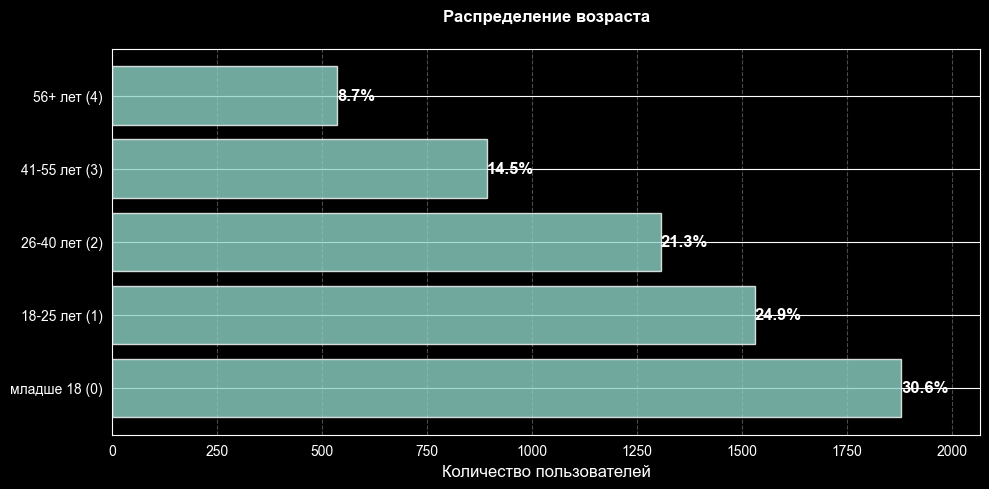

In [25]:
# Распределение возраста пользователей
plt.figure(figsize=(10, 5))

counts = df['age_category'].value_counts()
bars = plt.barh(['младше 18 (0)', '18-25 лет (1)', '26-40 лет (2)', '41-55 лет (3)', '56+ лет (4)'], counts.values, alpha=0.8)

for bar, count in zip(bars, counts.values):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2.,
        f'{count/len(df)*100:.1f}%',
        ha='left', va='center', fontsize=12, fontweight='bold'
    )

plt.title('Распределение возраста', fontsize=12, fontweight='bold', pad=20)
plt.xlabel('Количество пользователей', fontsize=12)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.xlim(0, max(counts.values) * 1.1)
plt.tight_layout()
plt.show()

В распределении видим плавное убывание классов от младшего к старшему:
- младше 18 летсоставляет 30.6%
- 18-25 лет составляет 24.9%
- 26-40 лет составляет 21.3%
- 41-55 лет составляет 14.5%
- 56+ лет составляет 8.7%
В кацестве основной метрики для оценки модели можно использовать F1-score.

#### 2.3 Анализ признаков


Для обучения модели не понадобится признак user_id так как он уникален и является идентификатором пользователя, этот признак можно сразу удалить.

#### 2.4 Анализ пропущенных значений


In [69]:
# Сколько строк имеют хотя бы один пропуск
rows_with_nan = df.isna().any(axis=1).sum()
print(f"\nСтрок с хотя бы одним пропуском: {rows_with_nan} из {len(df)} "
      f"({rows_with_nan/len(df)*100:.2f}%)")


Строк с хотя бы одним пропуском: 646 из 6146 (10.51%)


In [70]:
# Посчитаем количество и доли пропусков в столбцах
def show_missing_stats(tmp_df):
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': tmp_df.isnull().sum(),
        'Доля пропусков': tmp_df.isnull().mean().round(4)
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0].sort_values(by='Кол-во пропусков', ascending=False)
    return missing_stats.style.background_gradient(cmap='coolwarm') if not missing_stats.empty else "Пропусков в данных нет"
show_missing_stats(df)

,Кол-во пропусков,Доля пропусков
ads_activity,238,0.038700
primary_device,164,0.026700
cloud_usage,155,0.025200
surf_depth,117,0.019000


В датафрейме `df` обнаружено
- 238 пропусков в столбце `ads_activity` — это 4% данных. Пропуски в этом столбце, вероятно, связаны с тем, что пользователь не взаимодействовал с рекламными объявлениями. пропуски можно заменить модой.
- 164 пропусков в столбце `primary_device` - это 2% данных. Пропуски в этом столбце, вероятно, связаны с тем, что данные были потеряны или не записаны, пропуски можно заменить модой.
- 155 пропусков в столбце `cloud_usage` - это 2% данных. Пропуски в этом столбце, вероятно, связаны с тем, что пользователь не обращается к облачным ресурсам. Пропуски можно заменить на `False`.
- 117 пропусков в столбце `surf_depth` - это 2% данных. Пропуски в этом столбце, вероятно, связаны с тем, что пользователь не взаимодействовал с рекламными обхявлениями. пропуски можно заменить модой.

#### 2.5 Анализ категориальных признаков

In [28]:
# Посчитаем количество уникальных значений в категориальных столбцах
categories = (
    'age_category',
    'preferred_weekday',
    'first_daytime',
    'last_daytime',
    'preferred_daytime',
    'preferred_category',
    'first_category',
    'last_category',
    'ads_activity',
    'surf_depth',
    'primary_device',
)
def show_uniques_stats(tmp_df, columns):
    uniques = {col: tmp_df[col].nunique() for col in columns}
    uniques_stats = pd.DataFrame(list(uniques.items()), columns=["Столбец", "Уникальных значений"]).sort_values(by='Уникальных значений')
    return uniques_stats.style.background_gradient(cmap='coolwarm').set_caption("Статистика уникальных значений")
show_uniques_stats(df, categories)

,Столбец,Уникальных значений
4,preferred_daytime,3
9,surf_depth,3
2,first_daytime,4
3,last_daytime,4
10,primary_device,4
0,age_category,5
8,ads_activity,5
1,preferred_weekday,7
5,preferred_category,20
6,first_category,20


Признаки preferred_daytime, surf_depth, first_daytime, last_daytime, primary_device, age_category, ads_activity, preferred_weekday можно закодировать при помощи One-Hot Encoding, так как у этих признаков низкая координальность.
Признаки preferred_category, first_category, last_category лучше кодировать Target Encoding, так как количество уникальных значений выше 10 уникальных значений.

## Предобработка данных

In [29]:
# Удалим явные дубликаты
df = df.drop_duplicates(keep='last')

#### 2.6 Анализ выбросов и распределений


In [43]:
# Функция для отрисовки распределения по
def plot_distribution(tmp_df, bin_col, second_col, title, x_label, y_label='Плотность', figsize=(16, 6), fontsize=12, bins=40):
    fig, axes = plt.subplots(1, 2, figsize=figsize, gridspec_kw={'width_ratios': [2, 1]})
    age0 = tmp_df[tmp_df[bin_col]==0][second_col]
    age1 = tmp_df[tmp_df[bin_col]==1][second_col]
    age2 = tmp_df[tmp_df[bin_col]==2][second_col]
    age3 = tmp_df[tmp_df[bin_col]==3][second_col]
    age4 = tmp_df[tmp_df[bin_col]==4][second_col]

    ax1 = axes[0]
    ax1.hist(age0, bins=bins, alpha=0.5, label='младше 18 (0)', color='lightcoral', edgecolor='black', density=True)
    ax1.hist(age1, bins=bins, alpha=0.5, label='18-25 лет (1)', color='lightblue', edgecolor='black', density=True)
    ax1.hist(age2, bins=bins, alpha=0.5, label='26-40 лет (2)', color='lightskyblue', edgecolor='black', density=True)
    ax1.hist(age3, bins=bins, alpha=0.5, label='41-55 лет (3)', color='gold', edgecolor='black', density=True)
    ax1.hist(age4, bins=bins, alpha=0.5, label='56+ лет (4)', color='plum', edgecolor='black', density=True)

    ax1.set_title(title, fontsize=fontsize, fontweight='bold')
    ax1.set_xlabel(x_label)
    ax1.set_ylabel(y_label)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2 = axes[1]
    data_to_plot = [age0, age1, age2, age3, age4]
    box = ax2.boxplot(data_to_plot, vert=True, patch_artist=True, tick_labels=['младше 18 (0)', '18-25 лет (1)', '26-40 лет (2)', '41-55 лет (3)', '56+ лет (4)'])

    colors = ['lightcoral', 'lightblue', 'lightskyblue', 'gold', 'plum']
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax2.set_xlabel('Возрастная группа')
    ax2.set_title('Ящик с усами', fontsize=fontsize, fontweight='bold')
    ax2.grid(True, alpha=0.2, axis='x')

    plt.tight_layout()
    plt.show()

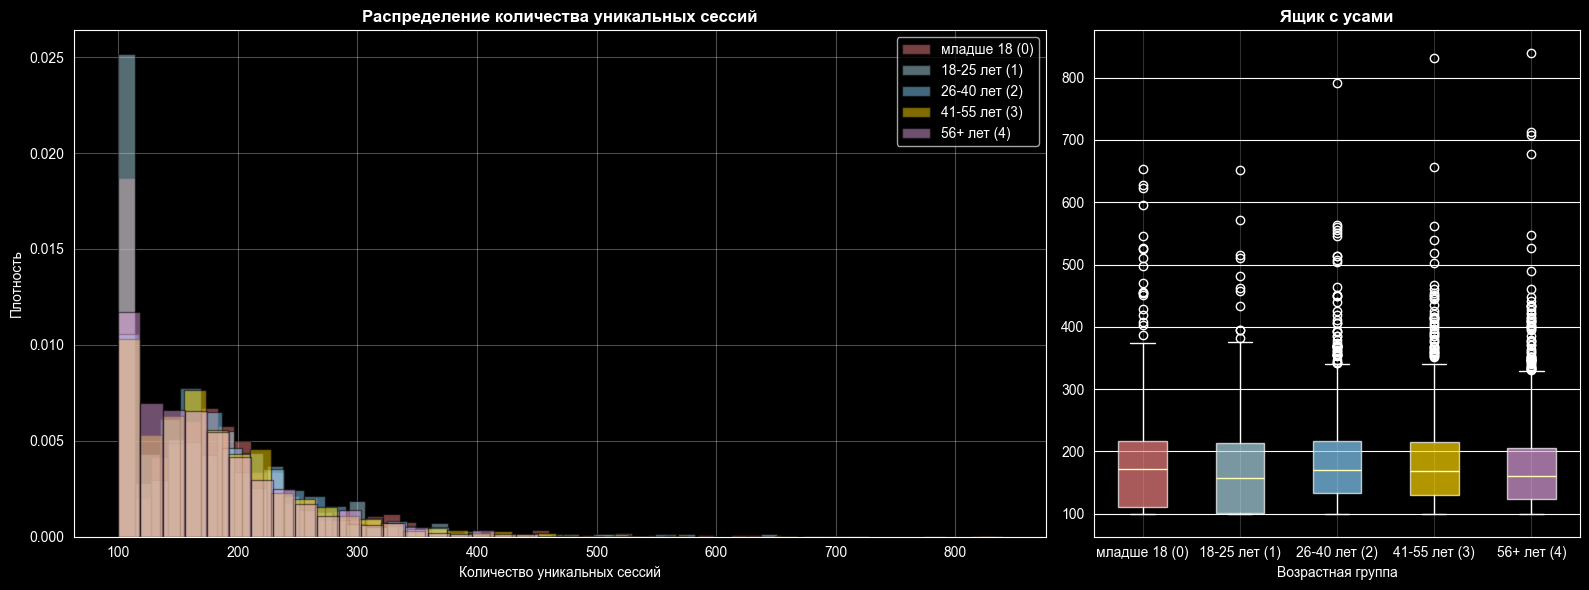

In [45]:
plot_distribution(df, 'age_category', 'unique_sessions',
            'Распределение количества уникальных сессий', 'Количество уникальных сессий', bins=40)

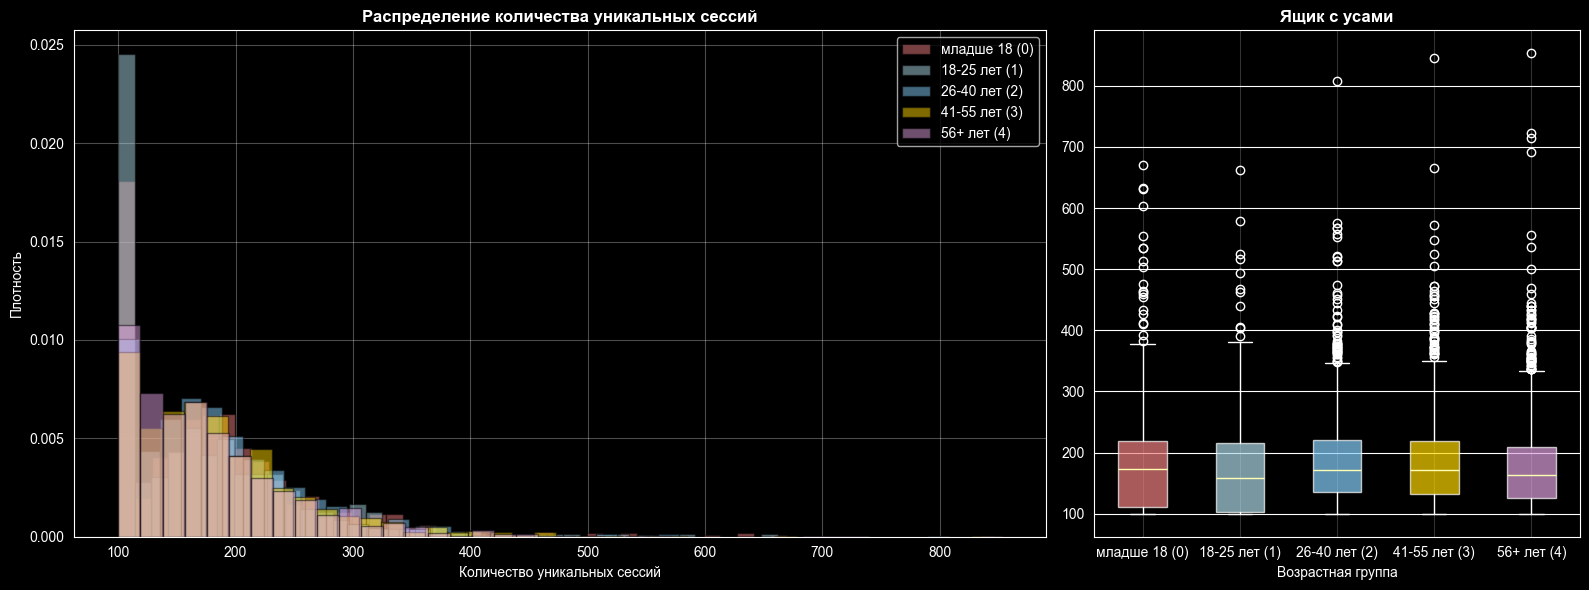

In [46]:
plot_distribution(df, 'age_category', 'total_actions',
            'Распределение количества действий', 'Количество действий', bins=40)

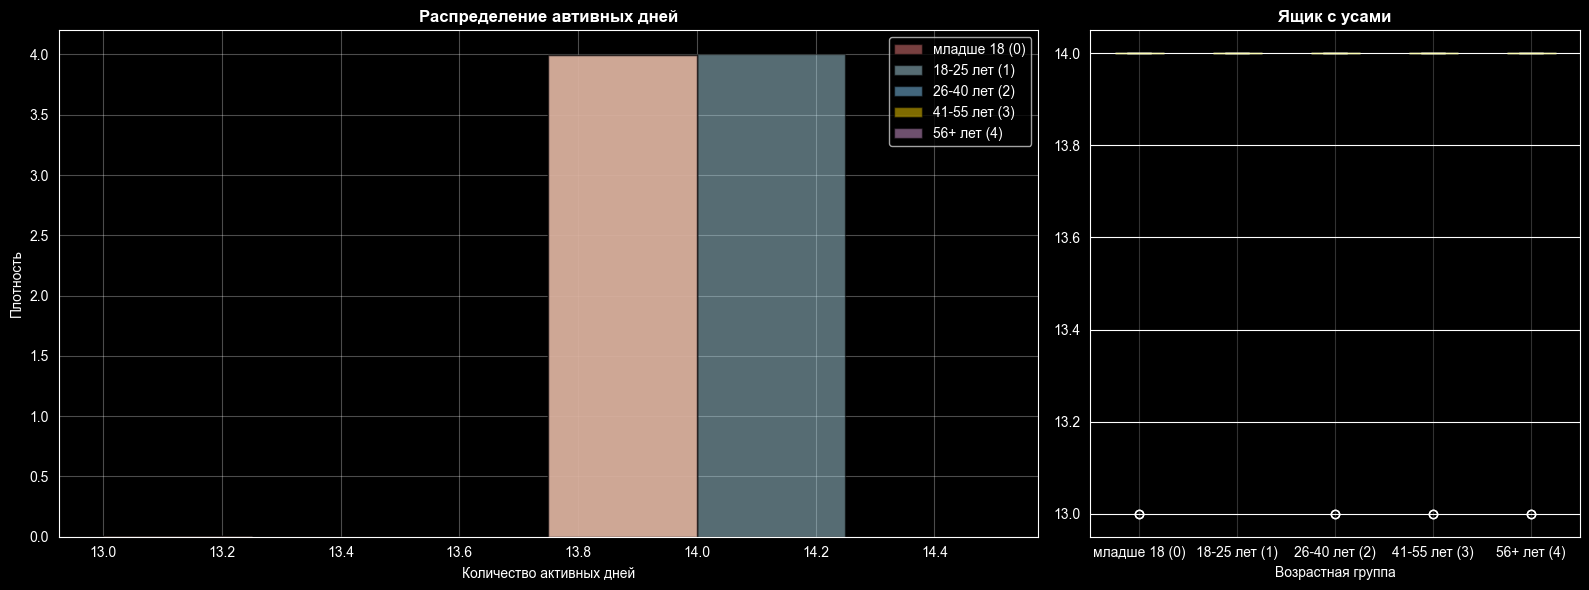

In [50]:
plot_distribution(df, 'age_category', 'active_days',
            'Распределение автивных дней', 'Количество активных дней', bins=4)

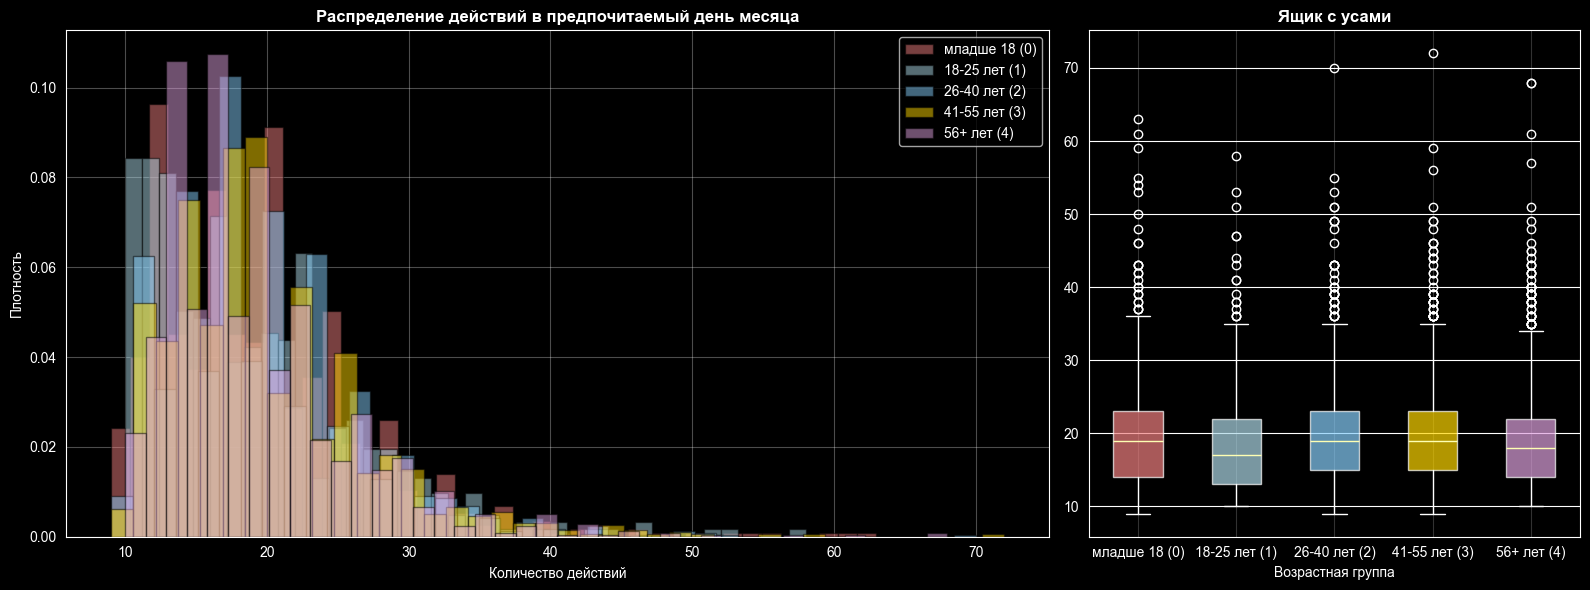

In [52]:
plot_distribution(df, 'age_category', 'actions_in_preferred_day_of_month',
            'Распределение действий в предпочтительный день месяца', 'Количество действий', bins=40)

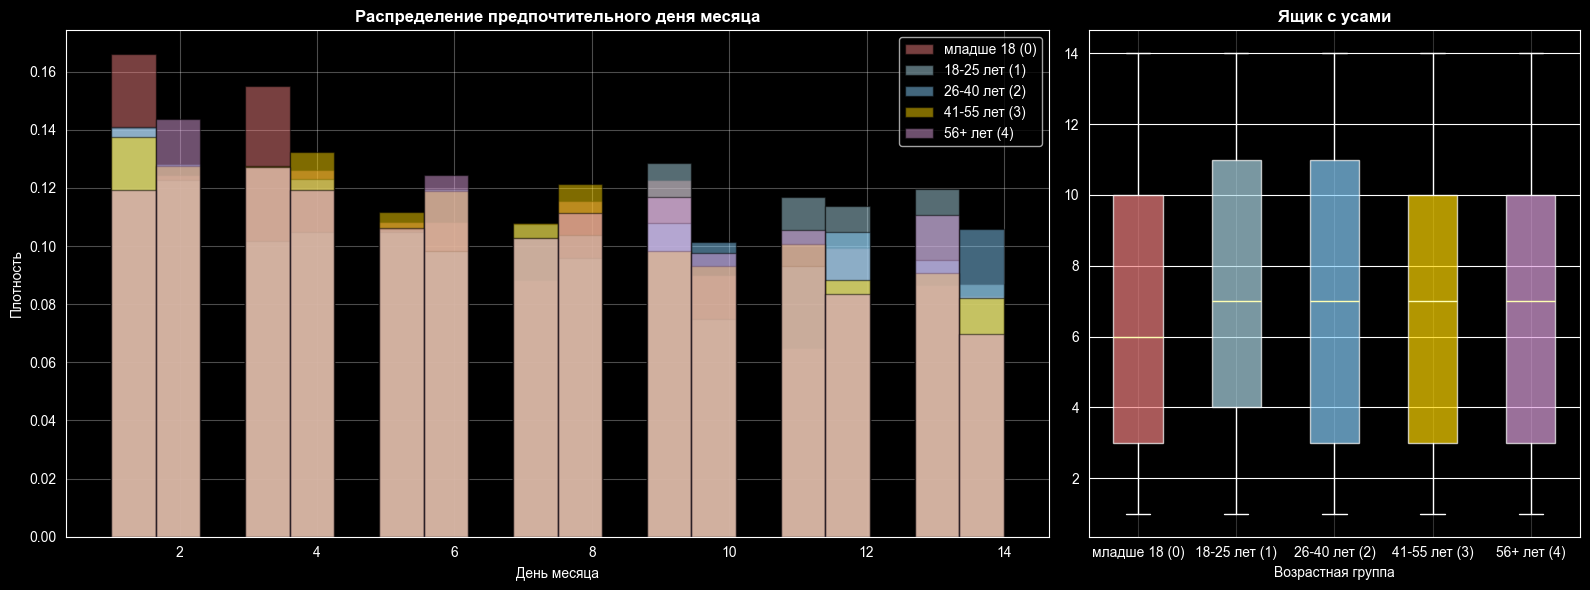

In [55]:
plot_distribution(df, 'age_category', 'preferred_day_of_month',
            'Распределение предпочтительного деня месяца', 'День месяца', bins=20)

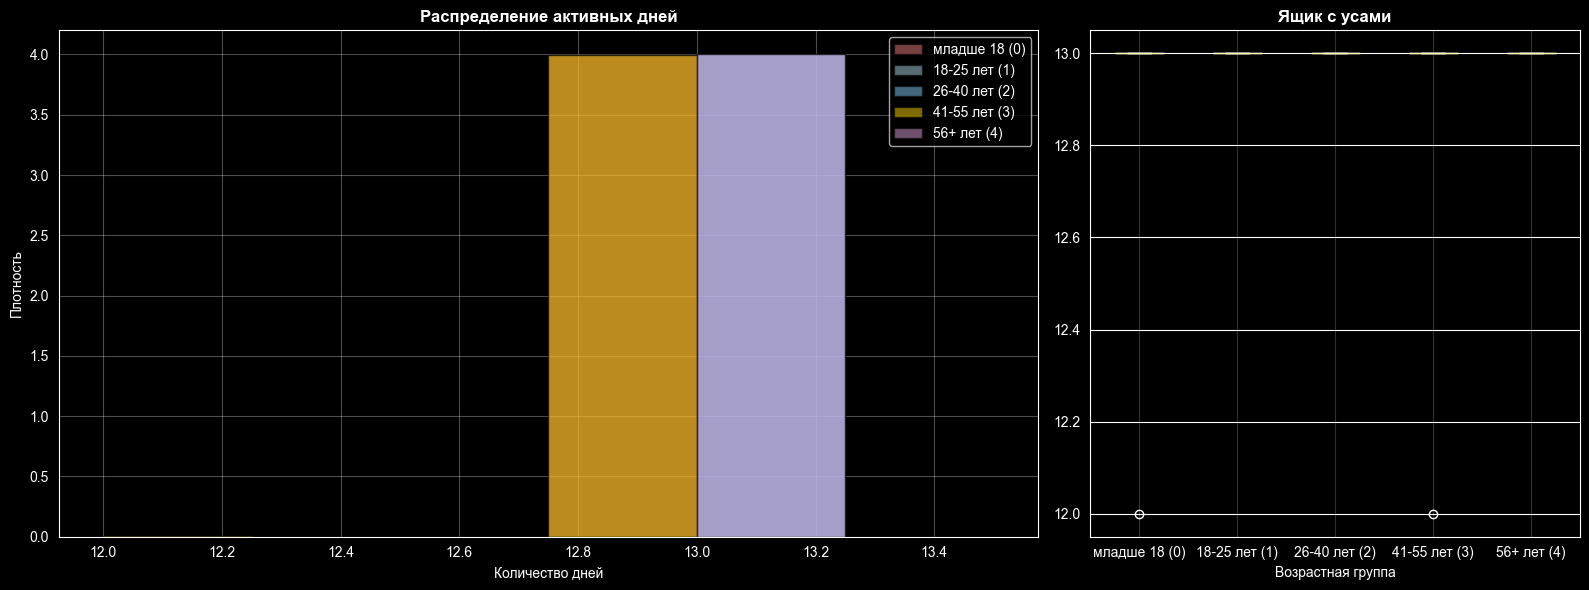

In [58]:
plot_distribution(df, 'age_category', 'total_days_span',
            'Распределение активных дней', 'Количество дней', bins=4)

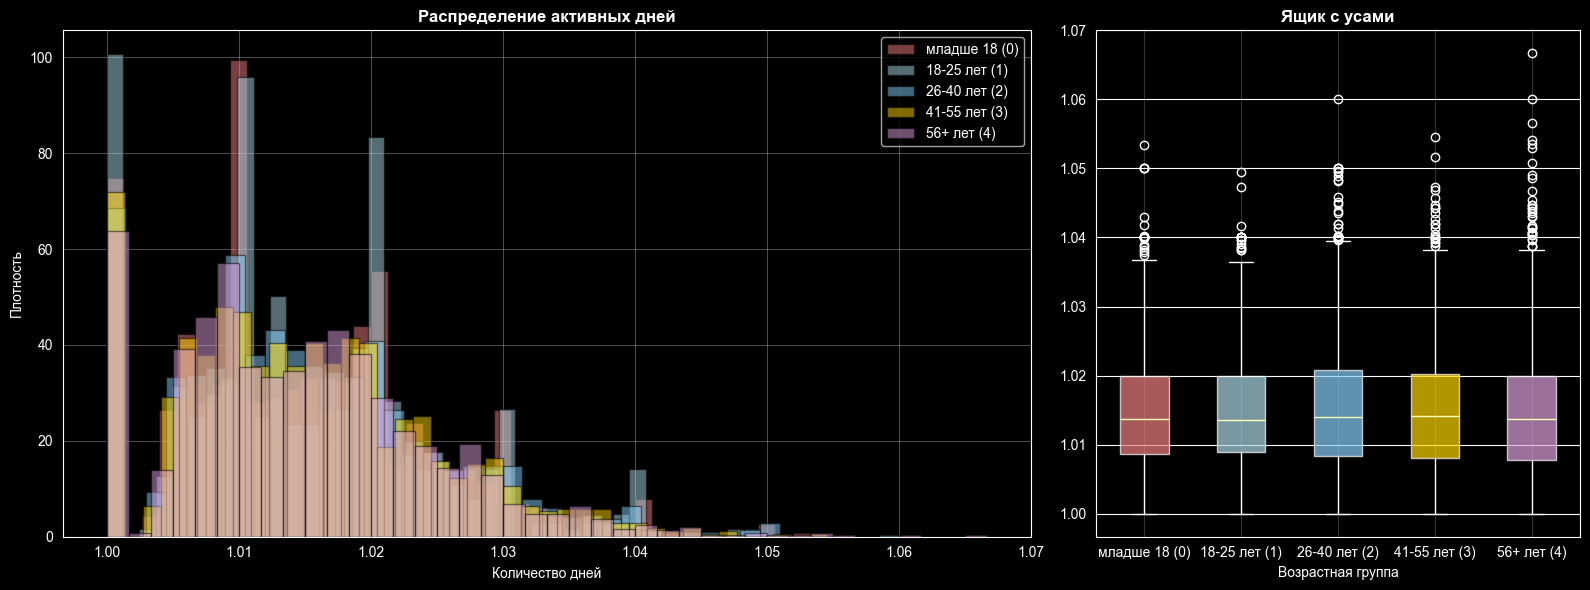

In [60]:
plot_distribution(df, 'age_category', 'actions_per_session',
            'Распределение действий на сессию', 'Количество действий', bins=40)

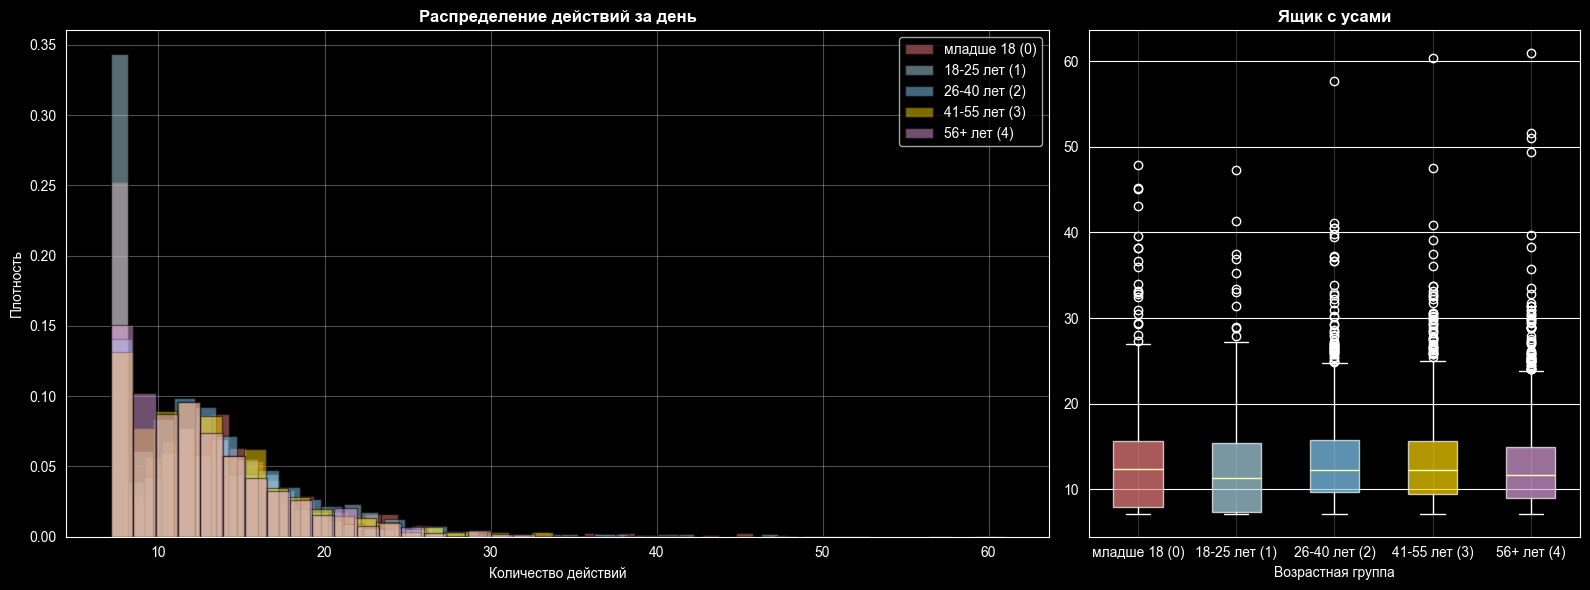

In [61]:
plot_distribution(df, 'age_category', 'actions_per_active_day',
            'Распределение действий за день', 'Количество действий', bins=40)

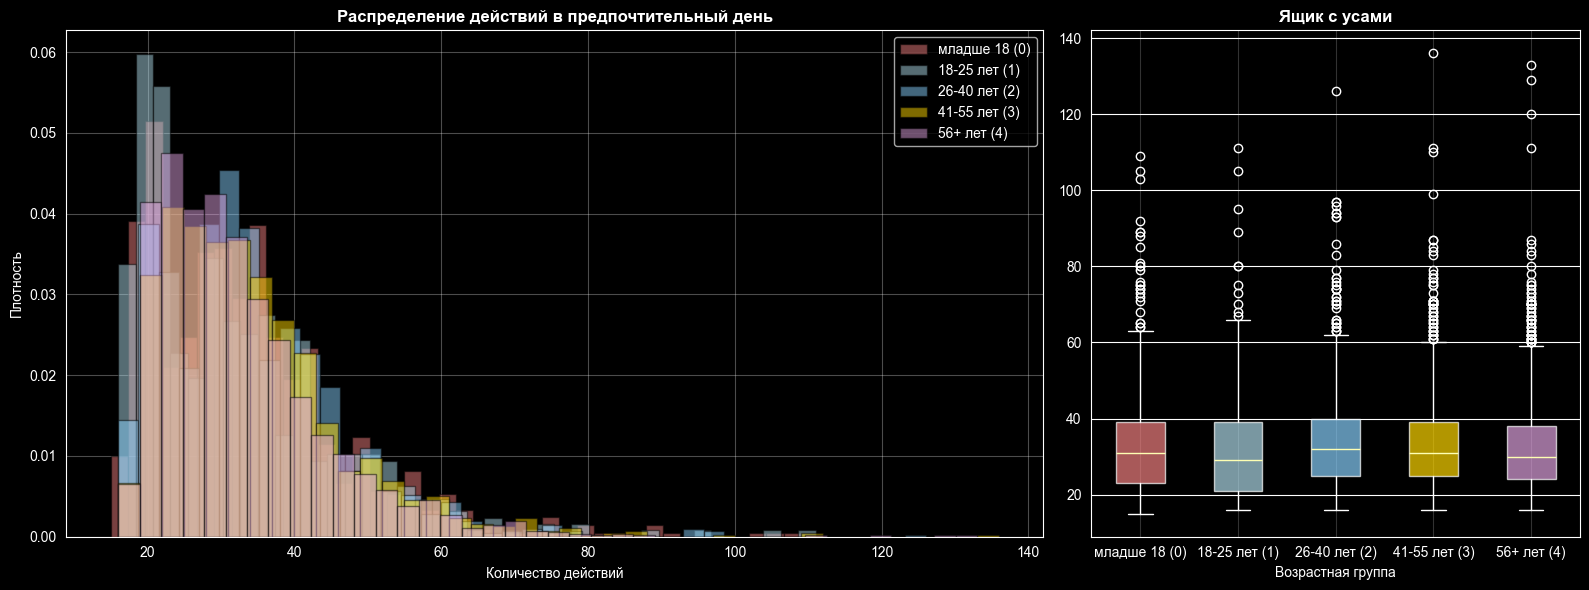

In [74]:
plot_distribution(df, 'age_category', 'actions_in_preferred_weekday',
            'Распределение действий в предпочтительный день', 'Количество действий', bins=40)

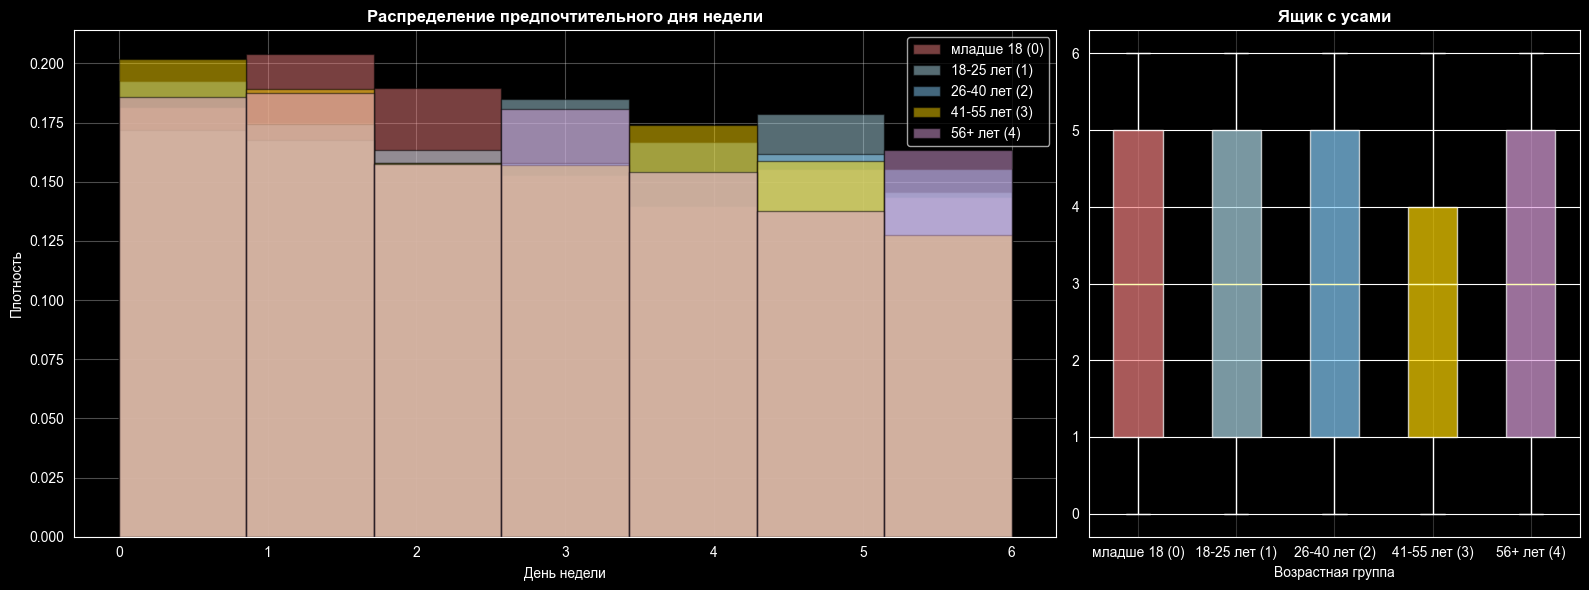

In [77]:
plot_distribution(df, 'age_category', 'preferred_weekday',
            'Распределение предпочтительного дня недели', 'День недели', bins=7)

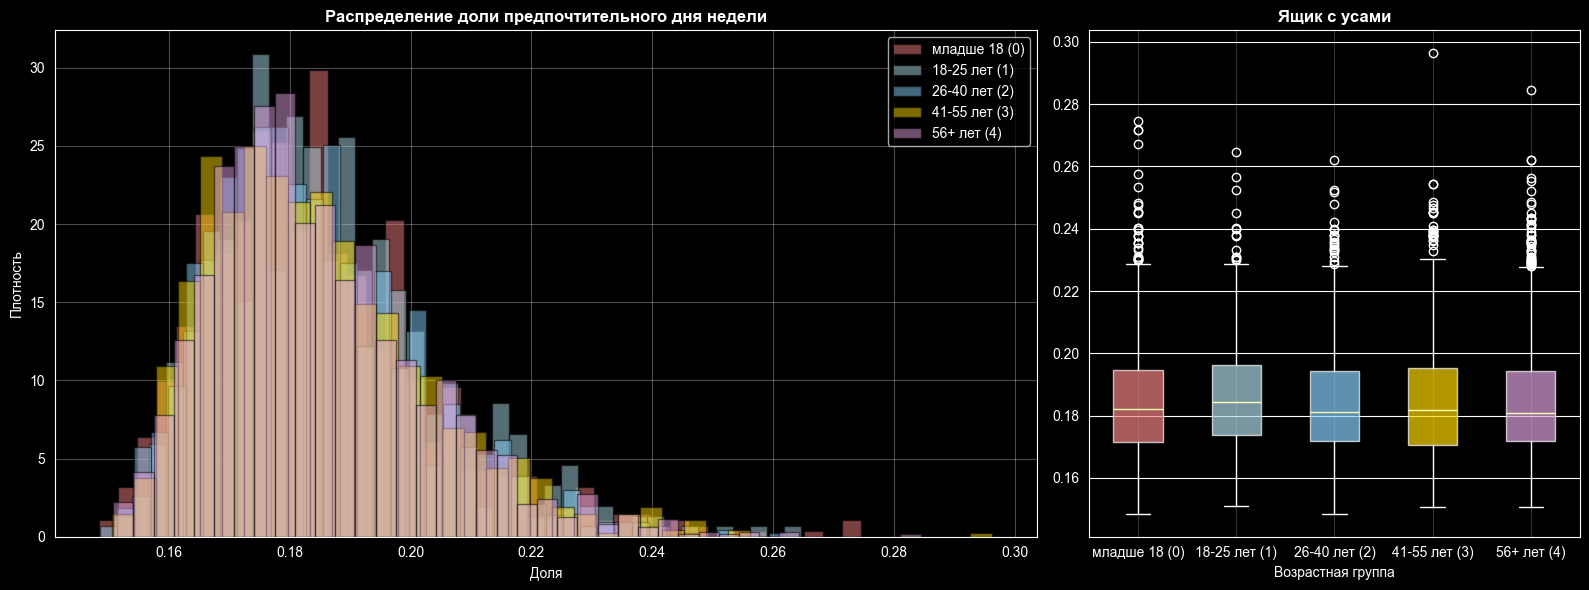

In [80]:
plot_distribution(df, 'age_category', 'preferred_weekday_ratio',
            'Распределение доли предпочтительного дня недели', 'Доля', bins=40)

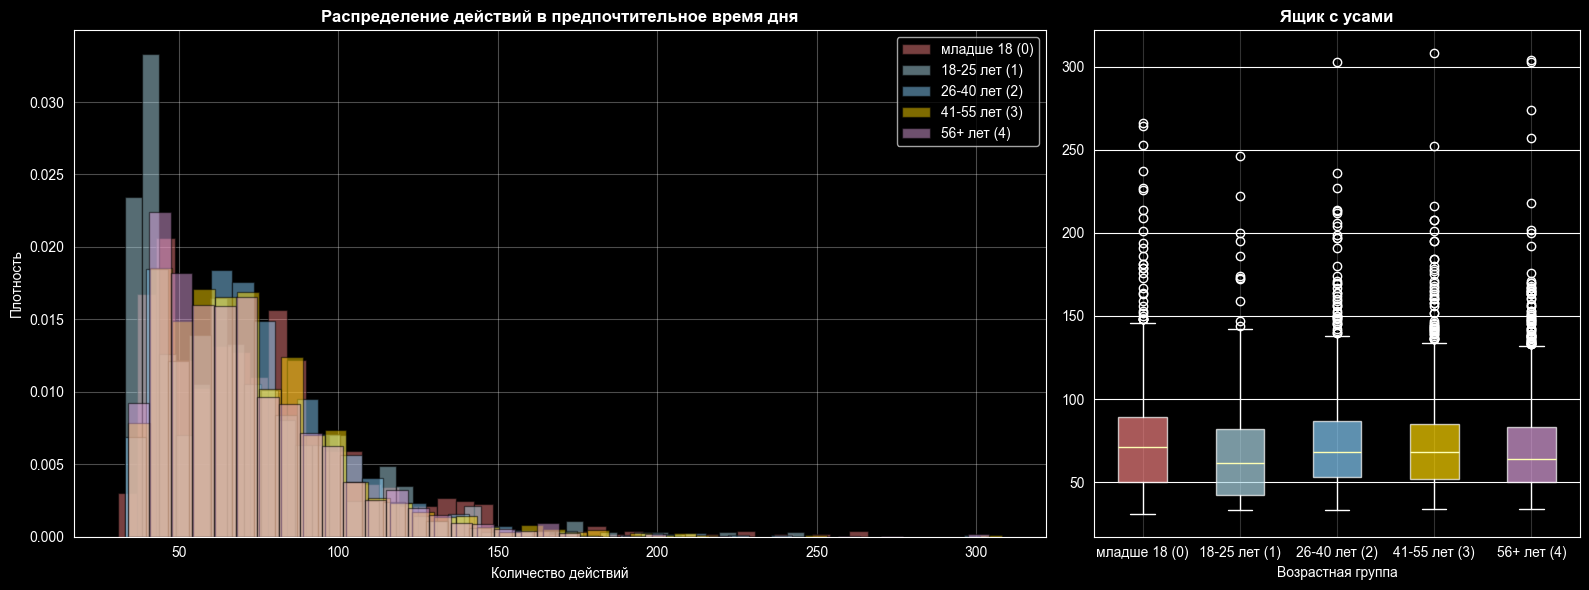

In [83]:
plot_distribution(df, 'age_category', 'actions_in_preferred_daytime',
            'Распределение действий в предпочтительное время дня', 'Количество действий', bins=40)

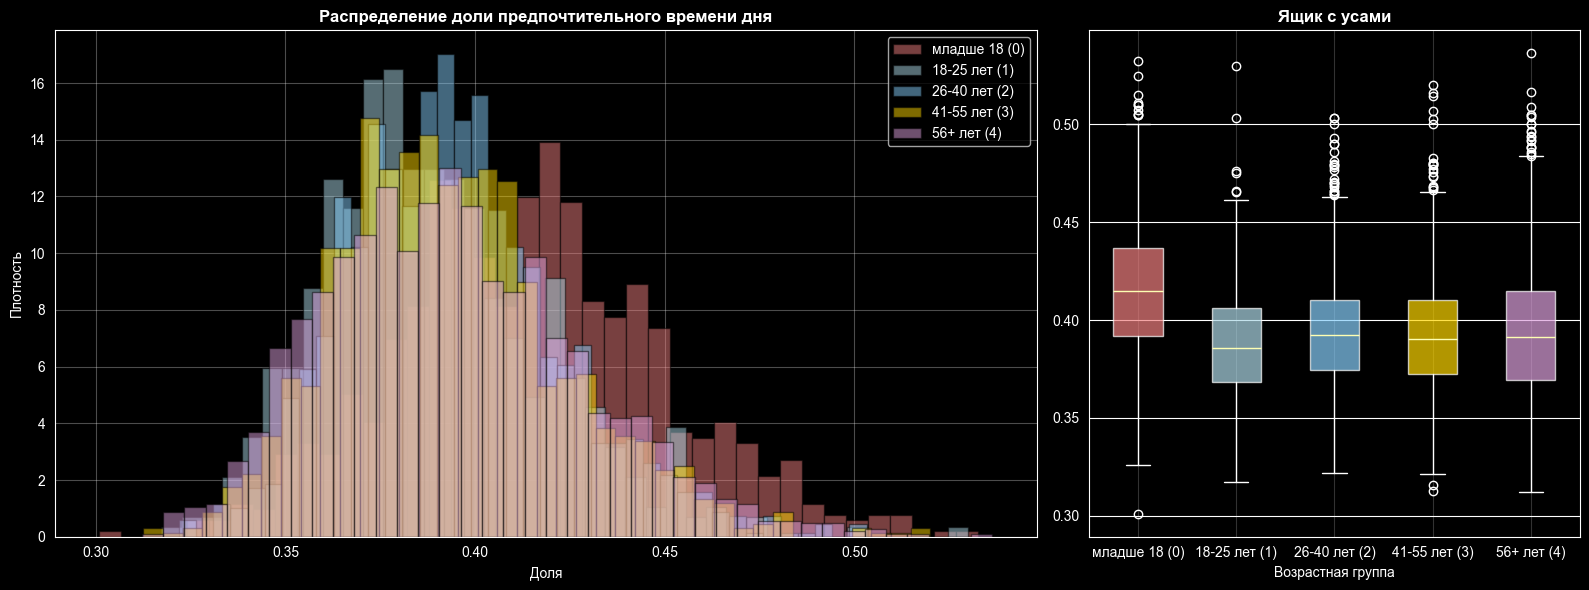

In [85]:
plot_distribution(df, 'age_category', 'preferred_daytime_ratio',
            'Распределение доли предпочтительного времени дня', 'Доля', bins=40)

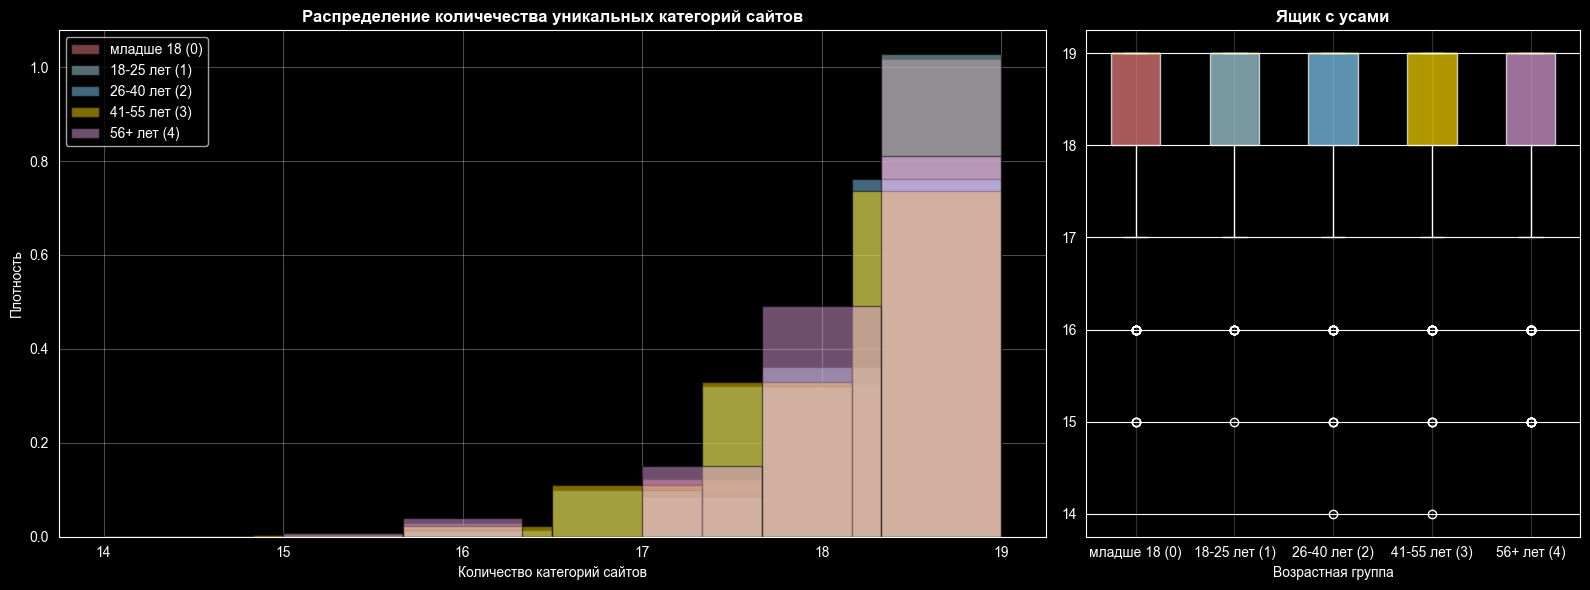

In [89]:
plot_distribution(df, 'age_category', 'unique_categories',
            'Распределение количечества уникальных категорий сайтов', 'Количество категорий сайтов', bins=6)

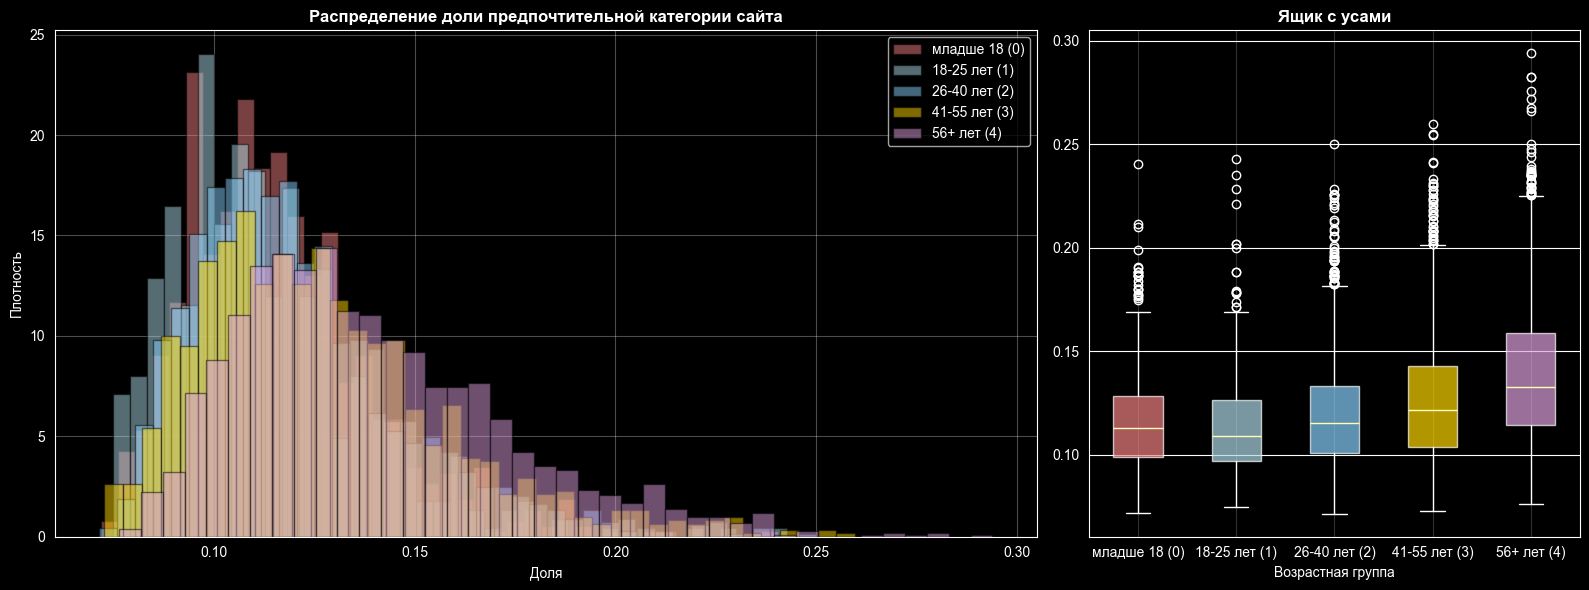

In [91]:
plot_distribution(df, 'age_category', 'preferred_category_ratio',
            'Распределение доли предпочтительной категории сайта', 'Доля', bins=40)

#### 2.7 Корреляции

In [96]:
interval_columns = [
    'unique_sessions',
    'total_actions',
    'active_days',
    'actions_in_preferred_day_of_month',
    'total_days_span',
    'actions_per_session',
    'actions_per_active_day',
    'actions_in_preferred_weekday',
    'actions_in_preferred_daytime',
    'preferred_weekday_ratio',
    'preferred_daytime_ratio',
    'unique_categories',
    'preferred_category_ratio',
    'preferred_day_of_month',
    'preferred_weekday'
]
columns = df.columns.tolist()
columns.remove('user_id')
correlation_matrix = phik.phik_matrix(df[columns], interval_cols=interval_columns, bins=5, verbose=False)

In [97]:
# Строим тепловую карту коэффициента phi_k
def plot_heatmap(corr_matrix):
    plt.figure(figsize=(12, 6))
    sns.heatmap(corr_matrix,
                annot=True,
                fmt='.2f',
                cmap='coolwarm',
                linewidths=0.5,
                cbar=False
               )
    plt.title('Тепловая карта коэффициента phi_k')
    plt.show()

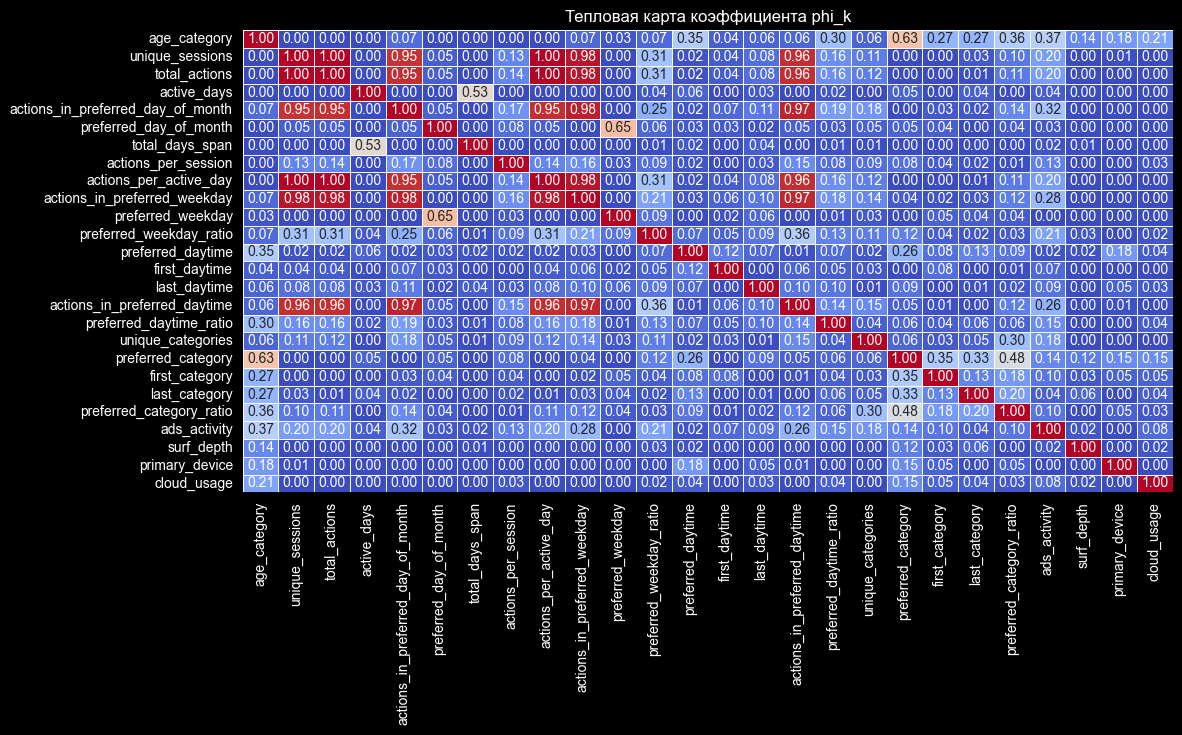

Exception ignored in: <function ResourceTracker.__del__ at 0x10ad9dda0>
Traceback (most recent call last):
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10ad31da0>
Traceback (most recent call last):
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3

In [98]:
# Строим тепловую карту коэффициента phi_k
plot_heatmap(correlation_matrix)

In [100]:
# создаем список с параметрами с высокой корреляцией между признаками
high_corr_all_features = ['unique_sessions', 'actions_in_preferred_weekday']

In [101]:
click_corr = correlation_matrix['age_category'].drop('age_category')
threshold = 0.02
low_threshold = 0.02
high_corr_features = click_corr[click_corr >= threshold]
zero_corr_features = click_corr[click_corr < low_threshold]

In [102]:
print(f"Признаки с корреляцией > {threshold}:")
print(high_corr_features.sort_values(ascending=False).head(10))
print(f"Признаки с корреляцией <= {low_threshold}:")
print(zero_corr_features.sort_values(ascending=False))

Признаки с корреляцией > 0.02:
preferred_category          0.626433
ads_activity                0.373374
preferred_category_ratio    0.355477
preferred_daytime           0.353461
preferred_daytime_ratio     0.301764
first_category              0.271114
last_category               0.267287
cloud_usage                 0.214836
primary_device              0.184037
surf_depth                  0.143816
Name: age_category, dtype: float64
Признаки с корреляцией <= 0.02:
unique_sessions           0.0
total_actions             0.0
active_days               0.0
preferred_day_of_month    0.0
total_days_span           0.0
actions_per_session       0.0
actions_per_active_day    0.0
Name: age_category, dtype: float64


In [103]:
# создаем списки с параметров с высокой и низкой корреляцией с целевой переменной
high_corr_w_click_features = high_corr_features.index.tolist()
zero_corr_w_click_features = zero_corr_features.index.tolist()

Exception ignored in: <function ResourceTracker.__del__ at 0x1070a9da0>
Traceback (most recent call last):
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x109809da0>
Traceback (most recent call last):
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/Users/maksimsesemov/.local/share/uv/python/cpython-3.13.7-macos-aarch64-none/lib/python3

Самая высокая корреляция с целевым признаком `age_category` у `preferred_category`, `ads_activity`, `preferred_category_ratio`, `preferred_daytime` и `preferred_daytime_ratio`.
Отсутствует корреляцию у признаков `unique_sessions`, `total_actions`, `active_days`, `preferred_day_of_month`, `total_days_span`, `actions_per_session`, `actions_per_active_day`, эти признаки можно удалить.

Судя по матрице корреляции и по данным датафрейма, параметры `unique_sessions` и `actions_in_preferred_weekday` дублируют друг друга и имеют коэффициент корреляции 1. Параметры `site_domain`, `app_domain` и `device_id``unique_sessions` и `actions_in_preferred_weekday` поместим в переменную для дальшейшего удаления.

In [104]:
# Создаем список с признаками для удаления
features_to_drop = zero_corr_w_click_features + high_corr_all_features + ['user_id']

#### 2.8 Выводы по EDA

В процессе исследования данных выделен признак с сильной связью `preferred_category`, так же есть четыре признака со средней связью `ads_activity`, `preferred_category_ratio`, `preferred_daytime` и `preferred_daytime_ratio`, остальные признаки с низкой связью. При этом обнаружено, что у признаков `unique_sessions` и `actions_in_preferred_weekday` сильные связи между собой, что говорит нам о колинеарности и возможной нестабильности весов для целевой переменно. Избыточные фичи добавлены в переменную `features_to_drop`.

Наибольее значимые признаки для модели:
- preferred_category          0.62
- ads_activity                0.37
- preferred_category_ratio    0.35
- preferred_daytime           0.35
- preferred_daytime_ratio     0.30

- Дальнейшие действия по предобработке данных:
Числовые признаки нужно масштабировать StandardScaler или MinMaxScaler.
Категориальные признаки с числом уникальных значений < 10 закодируем при помощи OneHotEncoder.
Все остальные категориальные признаки закодируем при помощи TargetEncoder.

## Обучение и оценка базовой модели

## Создание и отбор признаков

## Подбор гиперпараметров моделей

## Подготовка артефактов модели для внедрения

## Выводы о результатах работы